<a href="https://colab.research.google.com/github/eva-erco/Biologia-Genetica/blob/main/Biologia_Genetica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving genetica.csv to genetica.csv


In [ ]:
# ================= LIBRERIE =================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
import io

In [ ]:
# ================= LETTURA CSV =================
df = pd.read_csv(io.BytesIO(uploaded['genetica.csv']))

print(df.head())


  Generazione  Frequenza_Allele_Dominante  Presenza_Ambientale  \
0          F3                        0.90                    0   
1          F1                        0.43                    1   
2          F2                        0.77                    0   
3          F3                        0.67                    1   
4          F2                        0.75                    1   

  Tipo_Ereditarieta  Percentuale_Fenotipo_Dominante  
0        Incomplete                            59.8  
1        Mendeliana                            52.4  
2        Incomplete                            57.4  
3        Mendeliana                            68.1  
4        Poligenica                            43.9  


In [ ]:
# ================= STATISTICA DESCRITTIVA =================
print("\n=== STATISTICA DESCRITTIVA ===")
print(df.describe())


=== STATISTICA DESCRITTIVA ===
       Frequenza_Allele_Dominante  Presenza_Ambientale  \
count                   42.000000            42.000000   
mean                     0.684048             0.380952   
std                      0.126009             0.491507   
min                      0.430000             0.000000   
25%                      0.592500             0.000000   
50%                      0.690000             0.000000   
75%                      0.777500             1.000000   
max                      0.900000             1.000000   

       Percentuale_Fenotipo_Dominante  
count                       42.000000  
mean                        49.290476  
std                         14.488933  
min                         18.900000  
25%                         39.850000  
50%                         49.300000  
75%                         58.250000  
max                         83.300000  


In [ ]:
# ================= REGRESSIONE LINEARE SEMPLICE =================
X = df[['Frequenza_Allele_Dominante']]
y = df['Percentuale_Fenotipo_Dominante']

model = LinearRegression()
model.fit(X, y)

print("\n=== REGRESSIONE SEMPLICE ===")
print(f"Intercetta: {model.intercept_:.4f}")
print(f"Coefficiente: {model.coef_[0]:.4f}")
print(f"R²: {model.score(X, y):.4f}")


=== REGRESSIONE SEMPLICE ===
Intercetta: 12.7796
Coefficiente: 53.3748
R²: 0.2155


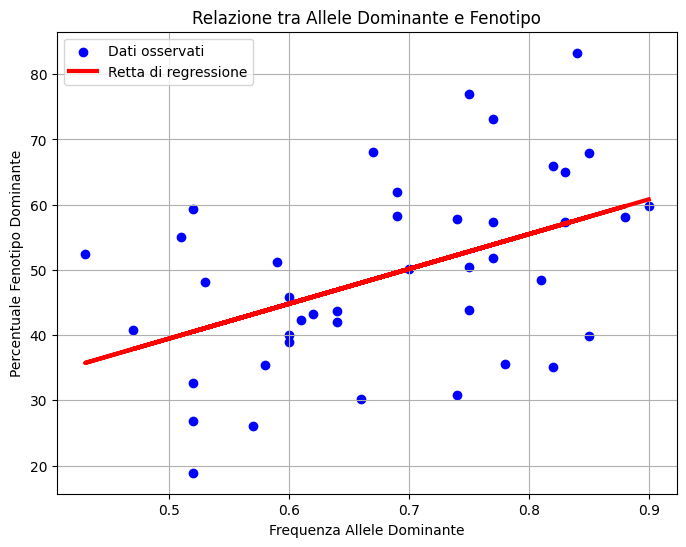

In [ ]:
# ================= GRAFICO REGRESSIONE =================
plt.figure(figsize=(8,6))

plt.scatter(
    df['Frequenza_Allele_Dominante'],
    df['Percentuale_Fenotipo_Dominante'],
    color='blue',
    label='Dati osservati'
)

plt.plot(
    df['Frequenza_Allele_Dominante'],
    model.predict(X),
    color='red',
    linewidth=3,
    label='Retta di regressione'
)

plt.xlabel('Frequenza Allele Dominante')
plt.ylabel('Percentuale Fenotipo Dominante')
plt.title('Relazione tra Allele Dominante e Fenotipo')
plt.legend()

plt.grid(True)
plt.show()

In [ ]:
# ================= CREAZIONE VARIABILI CATEGORICHE =================
df_encoded = pd.get_dummies(
    df,
    columns=['Generazione', 'Tipo_Ereditarieta'],
    drop_first=True
)

print(df_encoded.head())


   Frequenza_Allele_Dominante  Presenza_Ambientale  \
0                        0.90                    0   
1                        0.43                    1   
2                        0.77                    0   
3                        0.67                    1   
4                        0.75                    1   

   Percentuale_Fenotipo_Dominante  Generazione_F2  Generazione_F3  \
0                            59.8           False            True   
1                            52.4           False           False   
2                            57.4            True           False   
3                            68.1           False            True   
4                            43.9            True           False   

   Tipo_Ereditarieta_Mendeliana  Tipo_Ereditarieta_Poligenica  
0                         False                         False  
1                          True                         False  
2                         False                         False  
3   

In [ ]:
# ================= REGRESSIONE MULTIPLA =================
X_multi = df_encoded.drop(
    'Percentuale_Fenotipo_Dominante',
    axis=1
)

y_multi = df_encoded[
    'Percentuale_Fenotipo_Dominante'
]

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print("\n=== REGRESSIONE MULTIPLA ===")

for nome, coef in zip(
        X_multi.columns,
        model_multi.coef_):
    print(f"{nome}: {coef:.4f}")

print(f"\nIntercetta: {model_multi.intercept_:.4f}")
print(f"R² complessivo: {model_multi.score(X_multi, y_multi):.4f}")


=== REGRESSIONE MULTIPLA ===
Frequenza_Allele_Dominante: 58.1249
Presenza_Ambientale: 14.6239
Generazione_F2: -0.7801
Generazione_F3: -1.6784
Tipo_Ereditarieta_Mendeliana: 2.6317
Tipo_Ereditarieta_Poligenica: -16.5297

Intercetta: 7.9103
R² complessivo: 0.7944


/tmp/ipykernel_1730/1964472416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


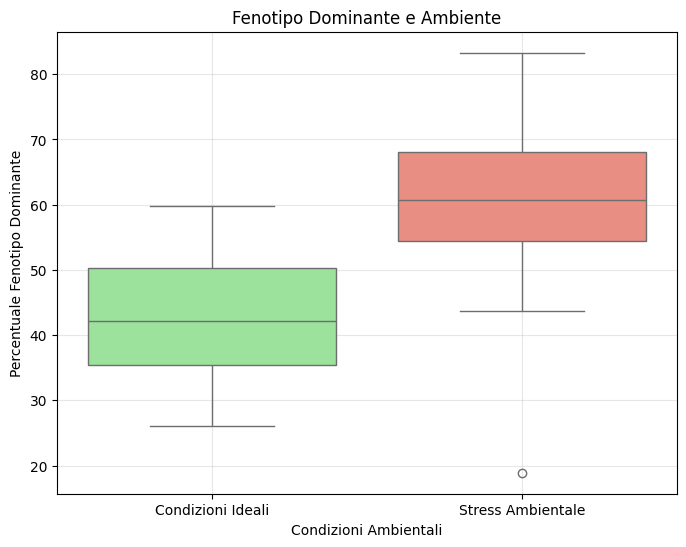

In [ ]:
# ================= BOXPLOT AMBIENTE =================
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Presenza_Ambientale',
    y='Percentuale_Fenotipo_Dominante',
    data=df,
    palette=['lightgreen','salmon']
)

plt.xticks(
    [0,1],
    ['Condizioni Ideali','Stress Ambientale']
)

plt.title('Fenotipo Dominante e Ambiente')
plt.xlabel('Condizioni Ambientali')
plt.ylabel('Percentuale Fenotipo Dominante')

plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ================= T-TEST =================
gruppo0 = df[
    df['Presenza_Ambientale'] == 0
]['Percentuale_Fenotipo_Dominante']

gruppo1 = df[
    df['Presenza_Ambientale'] == 1
]['Percentuale_Fenotipo_Dominante']

t_stat, p_value = stats.ttest_ind(
    gruppo0,
    gruppo1
)

print("\n=== T-TEST ===")
print(f"Media condizioni ideali: {gruppo0.mean():.2f}")
print(f"Media stress ambientale: {gruppo1.mean():.2f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Differenza statisticamente significativa")
else:
    print("Differenza NON significativa")


=== T-TEST ===
Media condizioni ideali: 43.00
Media stress ambientale: 59.51
t-statistic: -4.2728
p-value: 0.00012
Differenza statisticamente significativa


/tmp/ipykernel_1730/25515801.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


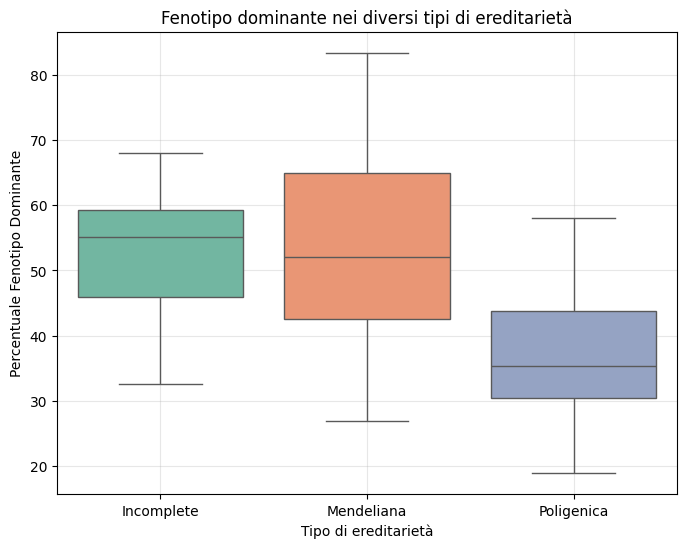

In [ ]:
# ================= GRAFICO EREDITARIETA =================
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Tipo_Ereditarieta',
    y='Percentuale_Fenotipo_Dominante',
    data=df,
    palette='Set2'
)

plt.title('Fenotipo dominante nei diversi tipi di ereditarietà')
plt.xlabel('Tipo di ereditarietà')
plt.ylabel('Percentuale Fenotipo Dominante')

plt.grid(True, alpha=0.3)
plt.show()


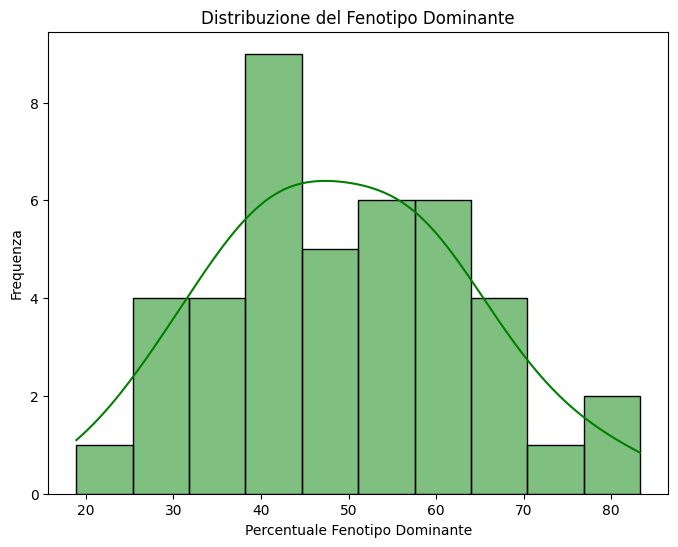

In [ ]:
# ================= ISTOGRAMMA =================
plt.figure(figsize=(8,6))

sns.histplot(
    df['Percentuale_Fenotipo_Dominante'],
    bins=10,
    kde=True,
    color='green'
)

plt.title('Distribuzione del Fenotipo Dominante')
plt.xlabel('Percentuale Fenotipo Dominante')
plt.ylabel('Frequenza')

plt.show()